#  EcoVision AI — Smart Waste Classification & Recycling Assistant

In [4]:
print("EcoVision AI — Smart Waste Classification & Recycling Assistant")
print("Deep Learning (CNN) Based Image Classification Project")

EcoVision AI — Smart Waste Classification & Recycling Assistant
Deep Learning (CNN) Based Image Classification Project


This project uses a Convolutional Neural Network (CNN) to classify waste images
into different categories and provide suitable recycling recommendations.


## Dataset download

In [1]:
!git clone https://github.com/garythung/trashnet.git

Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 6), reused 1 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 32.97 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
import os

print(os.listdir("trashnet"))

['.git', '.gitignore', 'plot.lua', 'DataLoader.lua', 'data', 'LICENSE', 'weight-init.lua', 'model.lua', 'shuffle.lua', 'utils.lua', 'train.lua', 'test.lua', 'README.md']


In [3]:
print(os.listdir("trashnet/data"))

['resize.py', 'dataset-resized.zip', 'zero-indexed-files.txt', 'one-indexed-files.txt', 'constants.py', 'one-indexed-files-notrash_train.txt', 'one-indexed-files-notrash_test.txt', 'one-indexed-files-notrash_val.txt']


##  Import Libraries

In [13]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Libraries imported successfully.")
print("TensorFlow Version:", tf.__version__)

Libraries imported successfully.
TensorFlow Version: 2.20.0


The required libraries have been imported for data handling, visualization,
image processing, and CNN-based deep learning model development.

##  Load Dataset

In [14]:
dataset_path = "trashnet/data"

print("Dataset Path:", dataset_path)
print("Dataset Exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("Dataset loaded successfully.")
else:
    print("Dataset path not found.")

Dataset Path: trashnet/data
Dataset Exists: True
Dataset loaded successfully.


The dataset path is defined and verified to ensure that the TrashNet dataset is
available before starting the exploratory data analysis.

##  Dataset Inspection

In [15]:
# Get all items inside the dataset directory
dataset_items = os.listdir(dataset_path)

print("Dataset Contents:")
print(dataset_items)

print("\nTotal Items:", len(dataset_items))

Dataset Contents:
['resize.py', 'dataset-resized.zip', 'zero-indexed-files.txt', 'one-indexed-files.txt', 'constants.py', 'one-indexed-files-notrash_train.txt', 'one-indexed-files-notrash_test.txt', 'one-indexed-files-notrash_val.txt']

Total Items: 8


The dataset directory is inspected to identify its contents and understand
the overall folder structure before performing detailed data analysis.

## Locate Dataset Archive

In [17]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "dataset-resized.zip":
            print("Dataset found at:")
            print(os.path.join(root, file))

Dataset found at:
/content/trashnet/data/dataset-resized.zip


The dataset archive is located by searching the Colab working directory so
that the exact file path can be used for extraction.

## Extract Dataset

In [18]:
import zipfile
import os

zip_path = "/content/trashnet/data/dataset-resized.zip"
extract_path = "/content/trashnet/data/dataset-resized"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("\nExtracted contents:")

for item in os.listdir(extract_path):
    print(item)

Dataset extracted successfully.

Extracted contents:
__MACOSX
dataset-resized


The compressed dataset has been extracted successfully so that the image
folders and files can be inspected for further exploratory data analysis.

## Inspect Extracted Dataset

In [19]:
import os

extracted_dataset_path = "/content/trashnet/data/dataset-resized/dataset-resized"

print("Dataset Path:", extracted_dataset_path)
print("\nDataset Contents:")

for item in os.listdir(extracted_dataset_path):
    print(item)

Dataset Path: /content/trashnet/data/dataset-resized/dataset-resized

Dataset Contents:
paper
plastic
glass
cardboard
.DS_Store
metal
trash


The extracted dataset directory is inspected to identify the available waste
categories before performing detailed data analysis and cleaning.

## Identify Dataset Classes

In [20]:
# Define the actual dataset path
dataset_path = "/content/trashnet/data/dataset-resized/dataset-resized"

# Identify only directories as classes
classes = sorted([
    item for item in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, item))
])

print("Waste Categories:")
for index, class_name in enumerate(classes):
    print(f"{index}: {class_name}")

print("\nTotal Classes:", len(classes))

Waste Categories:
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash

Total Classes: 6


The dataset contains six waste categories. Only directories are considered as
valid classes, while metadata files such as .DS_Store are automatically ignored.

## Count Images per Class

In [21]:
class_counts = {}

valid_extensions = (".jpg", ".jpeg", ".png")

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    class_counts[class_name] = len(image_files)

total_images = sum(class_counts.values())

print("Images per class:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal Images:", total_images)

Images per class:

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137

Total Images: 2527


The number of valid image files is calculated for each waste category to
understand the dataset size and identify any possible class imbalance.

## Visualize Class Distribution

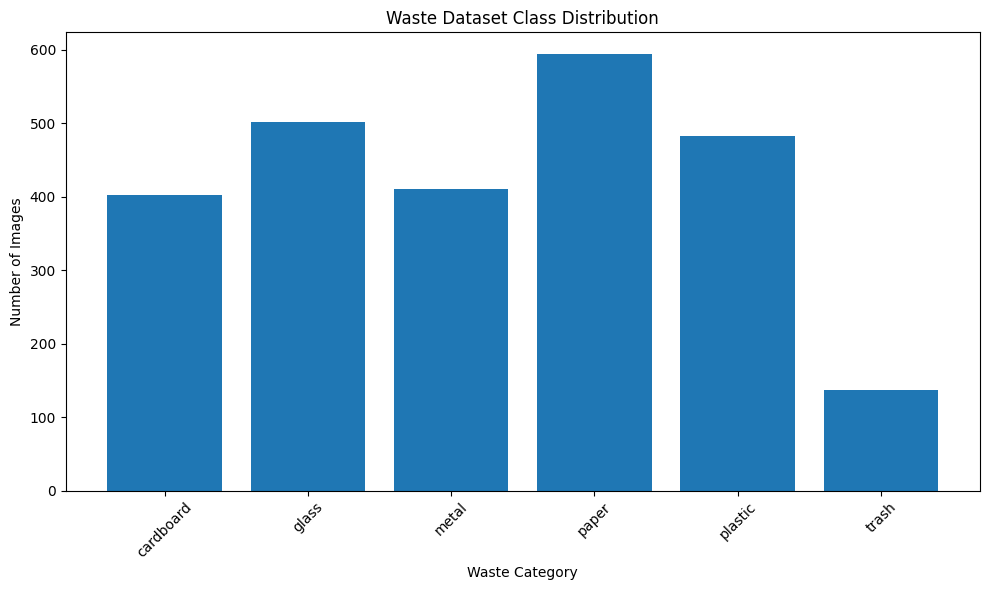

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Waste Dataset Class Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The class distribution is visualized to clearly compare the number of images
available in each waste category and identify class imbalance.

## Visualize Sample Images


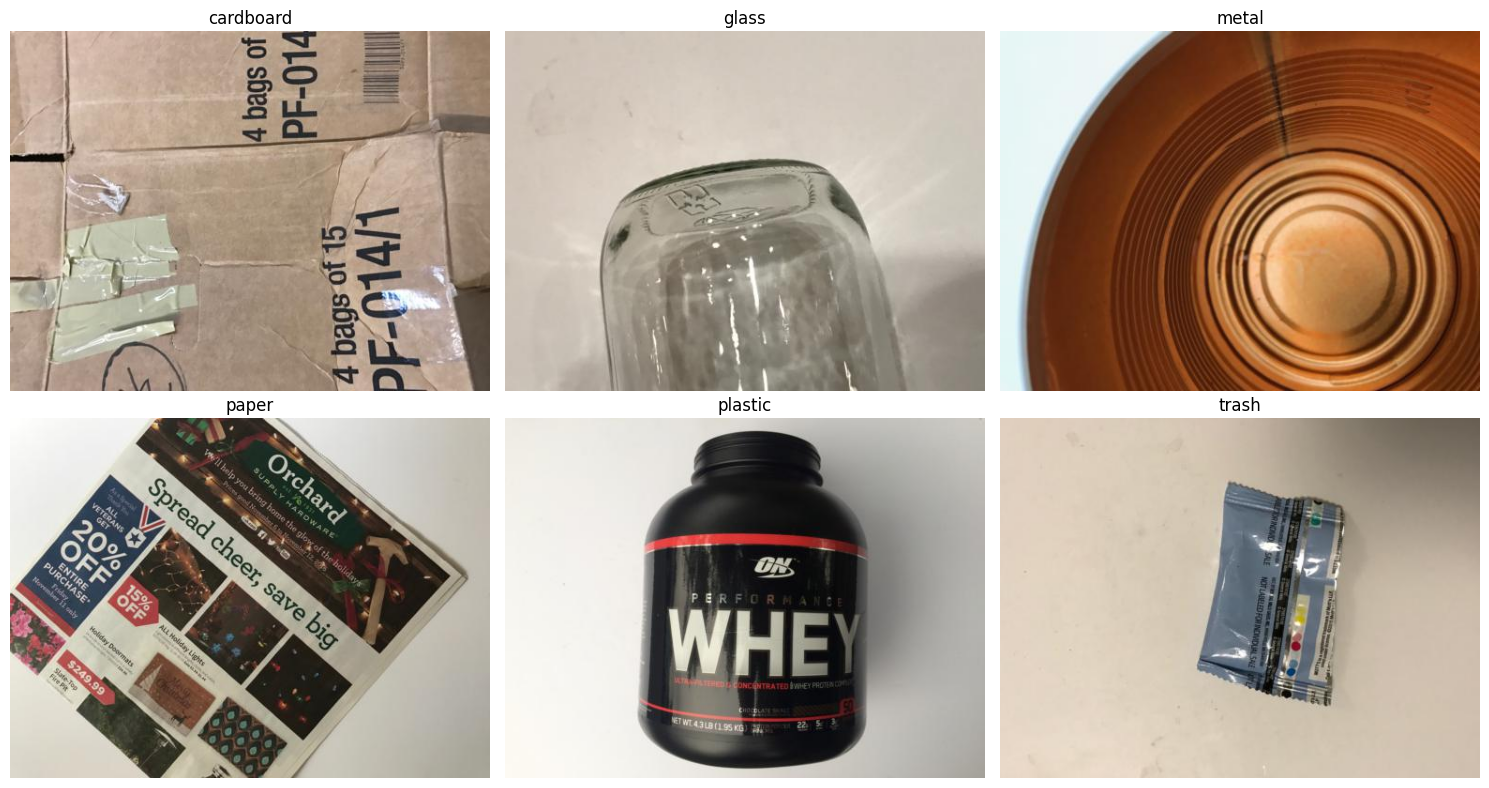

In [23]:
plt.figure(figsize=(15, 8))

for index, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    # Select the first image from each class
    image_path = os.path.join(class_path, image_files[0])

    image = Image.open(image_path)

    plt.subplot(2, 3, index + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Representative images from each waste category are visualized to understand
the visual characteristics and variations present across different classes.

## Analyze Image Dimensions

In [24]:
image_dimensions = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with Image.open(image_path) as image:
            width, height = image.size

        image_dimensions.append({
            "Class": class_name,
            "Width": width,
            "Height": height
        })

dimensions_df = pd.DataFrame(image_dimensions)

print("Total Images Analyzed:", len(dimensions_df))
dimensions_df.head()

Total Images Analyzed: 2527


,Class,Width,Height
0,cardboard,512,384
1,cardboard,512,384
2,cardboard,512,384
3,cardboard,512,384
4,cardboard,512,384


The dimensions of all valid images are analyzed to understand the variation in
image sizes before applying a fixed input size during CNN preprocessing.

## Image Dimension Statistics

In [25]:
print("Width Statistics:")
print(dimensions_df["Width"].describe())

print("\nHeight Statistics:")
print(dimensions_df["Height"].describe())

print("\nUnique Widths:", dimensions_df["Width"].nunique())
print("Unique Heights:", dimensions_df["Height"].nunique())

Width Statistics:
count    2527.0
mean      512.0
std         0.0
min       512.0
25%       512.0
50%       512.0
75%       512.0
max       512.0
Name: Width, dtype: float64

Height Statistics:
count    2527.0
mean      384.0
std         0.0
min       384.0
25%       384.0
50%       384.0
75%       384.0
max       384.0
Name: Height, dtype: float64

Unique Widths: 1
Unique Heights: 1


The statistical summary of image dimensions is analyzed to determine whether
the dataset contains consistent or varying image resolutions.

## Analyze Image Color Modes

In [26]:
color_modes = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with Image.open(image_path) as image:
            mode = image.mode

        color_modes[mode] = color_modes.get(mode, 0) + 1

print("Image Color Modes:")
for mode, count in color_modes.items():
    print(f"{mode}: {count}")

Image Color Modes:
RGB: 2527


The color mode of each image is analyzed to determine whether the dataset
contains RGB, grayscale, or other image formats before CNN preprocessing.

## Check Corrupted Images

In [27]:
corrupted_images = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        try:
            with Image.open(image_path) as image:
                image.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Total Images Checked:", len(dimensions_df))
print("Corrupted Images:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted image files:")
    for image in corrupted_images:
        print(image)
else:
    print("No corrupted images found.")

Total Images Checked: 2527
Corrupted Images: 0
No corrupted images found.


Each image is verified to ensure that it can be successfully opened and read.
Corrupted or unreadable images are identified before model training.

## Check Duplicate Images

In [28]:
import hashlib

image_hashes = {}
duplicate_images = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    for file in image_files:
        image_path = os.path.join(class_path, file)

        with open(image_path, "rb") as image_file:
            image_hash = hashlib.md5(image_file.read()).hexdigest()

        if image_hash in image_hashes:
            duplicate_images.append({
                "Duplicate Image": image_path,
                "Original Image": image_hashes[image_hash]
            })
        else:
            image_hashes[image_hash] = image_path

print("Total Images Checked:", len(image_hashes) + len(duplicate_images))
print("Unique Images:", len(image_hashes))
print("Duplicate Images:", len(duplicate_images))

if duplicate_images:
    print("\nDuplicate images found:")
    for duplicate in duplicate_images:
        print(duplicate)
else:
    print("No duplicate images found.")

Total Images Checked: 2527
Unique Images: 2524
Duplicate Images: 3

Duplicate images found:
{'Duplicate Image': '/content/trashnet/data/dataset-resized/dataset-resized/metal/metal91.jpg', 'Original Image': '/content/trashnet/data/dataset-resized/dataset-resized/glass/glass115.jpg'}
{'Duplicate Image': '/content/trashnet/data/dataset-resized/dataset-resized/plastic/plastic152.jpg', 'Original Image': '/content/trashnet/data/dataset-resized/dataset-resized/glass/glass176.jpg'}
{'Duplicate Image': '/content/trashnet/data/dataset-resized/dataset-resized/plastic/plastic332.jpg', 'Original Image': '/content/trashnet/data/dataset-resized/dataset-resized/glass/glass389.jpg'}


Duplicate images are identified using file hashes to ensure that identical
images are not unnecessarily repeated in the dataset.

## Visualize Duplicate Images

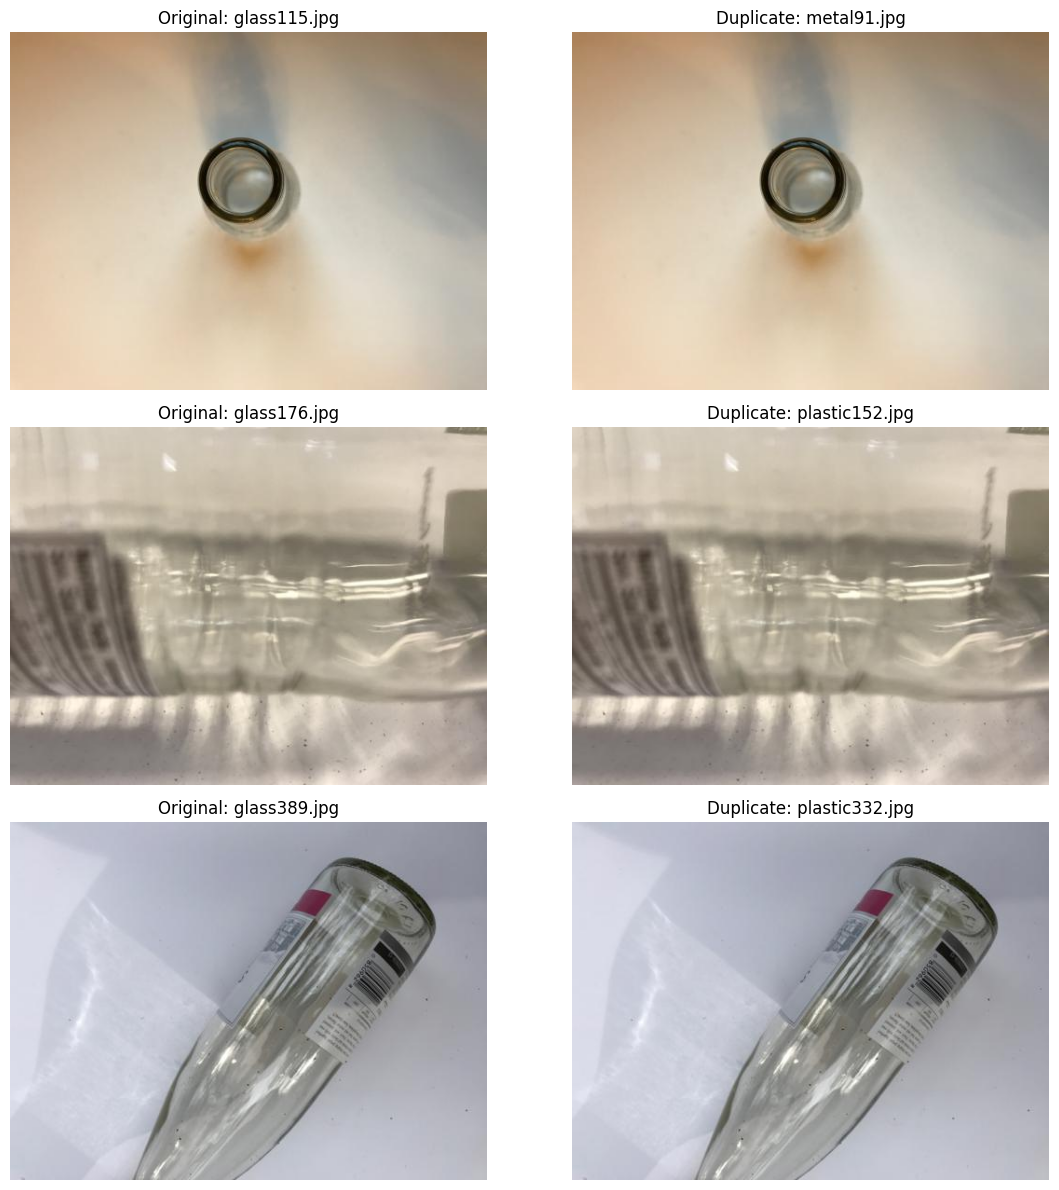

In [29]:
plt.figure(figsize=(12, 12))

for index, duplicate in enumerate(duplicate_images):

    original_path = duplicate["Original Image"]
    duplicate_path = duplicate["Duplicate Image"]

    original_image = Image.open(original_path)
    duplicate_image = Image.open(duplicate_path)

    plt.subplot(3, 2, index * 2 + 1)
    plt.imshow(original_image)
    plt.title(f"Original: {os.path.basename(original_path)}")
    plt.axis("off")

    plt.subplot(3, 2, index * 2 + 2)
    plt.imshow(duplicate_image)
    plt.title(f"Duplicate: {os.path.basename(duplicate_path)}")
    plt.axis("off")

plt.tight_layout()
plt.show()

The detected duplicate pairs are visually compared to confirm that the images
are truly identical and to identify any conflicting class labels.

## Create Clean Dataset

In [30]:
import shutil

clean_dataset_path = "/content/EcoVision_AI/clean_dataset"

# Create clean dataset directory
if os.path.exists(clean_dataset_path):
    shutil.rmtree(clean_dataset_path)

shutil.copytree(dataset_path, clean_dataset_path)

# Remove confirmed duplicate images from the clean copy
for duplicate in duplicate_images:
    duplicate_path = duplicate["Duplicate Image"]

    relative_path = os.path.relpath(
        duplicate_path,
        dataset_path
    )

    clean_duplicate_path = os.path.join(
        clean_dataset_path,
        relative_path
    )

    os.remove(clean_duplicate_path)

print("Clean dataset created successfully.")
print("Original dataset remains unchanged.")
print("Removed duplicate images:", len(duplicate_images))

Clean dataset created successfully.
Original dataset remains unchanged.
Removed duplicate images: 3


A separate clean copy of the dataset has been created while preserving the
original dataset. The three confirmed duplicate images were removed from the
clean dataset.

## Verify Clean Dataset

In [31]:
clean_class_counts = {}

for class_name in classes:
    class_path = os.path.join(clean_dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    clean_class_counts[class_name] = len(image_files)

clean_total_images = sum(clean_class_counts.values())

print("Clean Dataset Summary")
print("-" * 30)

for class_name, count in clean_class_counts.items():
    print(f"{class_name}: {count}")

print("-" * 30)
print("Total Images:", clean_total_images)
print("Images Removed:", total_images - clean_total_images)

Clean Dataset Summary
------------------------------
cardboard: 403
glass: 501
metal: 409
paper: 594
plastic: 480
trash: 137
------------------------------
Total Images: 2524
Images Removed: 3


The cleaned dataset is verified to confirm the final number of images in each
class and ensure that the identified duplicate images were successfully removed.

## Create Train, Validation and Test Split

In [32]:
import os
import shutil
import random

random.seed(42)

split_dataset_path = "/content/EcoVision_AI/split_dataset"

train_path = os.path.join(split_dataset_path, "train")
val_path = os.path.join(split_dataset_path, "validation")
test_path = os.path.join(split_dataset_path, "test")

# Create fresh split directories
if os.path.exists(split_dataset_path):
    shutil.rmtree(split_dataset_path)

for path in [train_path, val_path, test_path]:
    os.makedirs(path, exist_ok=True)

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

for class_name in classes:

    source_class_path = os.path.join(clean_dataset_path, class_name)

    image_files = [
        file for file in os.listdir(source_class_path)
        if file.lower().endswith(valid_extensions)
    ]

    random.shuffle(image_files)

    total = len(image_files)

    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_files = image_files[:train_end]
    val_files = image_files[train_end:val_end]
    test_files = image_files[val_end:]

    # Create class folders
    for split_path in [train_path, val_path, test_path]:
        os.makedirs(
            os.path.join(split_path, class_name),
            exist_ok=True
        )

    # Copy images
    for file in train_files:
        shutil.copy2(
            os.path.join(source_class_path, file),
            os.path.join(train_path, class_name, file)
        )

    for file in val_files:
        shutil.copy2(
            os.path.join(source_class_path, file),
            os.path.join(val_path, class_name, file)
        )

    for file in test_files:
        shutil.copy2(
            os.path.join(source_class_path, file),
            os.path.join(test_path, class_name, file)
        )

print("Dataset split completed successfully.")
print("Train:", train_path)
print("Validation:", val_path)
print("Test:", test_path)

Dataset split completed successfully.
Train: /content/EcoVision_AI/split_dataset/train
Validation: /content/EcoVision_AI/split_dataset/validation
Test: /content/EcoVision_AI/split_dataset/test


The cleaned dataset has been divided into training, validation, and test sets
using a 70:15:15 ratio to support reliable CNN training and evaluation.

## Verify Dataset Split

In [33]:
split_counts = {}

for split_name, split_path in {
    "Train": train_path,
    "Validation": val_path,
    "Test": test_path
}.items():

    split_counts[split_name] = {}

    for class_name in classes:

        class_path = os.path.join(split_path, class_name)

        image_files = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(valid_extensions)
        ]

        split_counts[split_name][class_name] = len(image_files)

split_counts_df = pd.DataFrame(split_counts)

print("Images per class in each split:")
display(split_counts_df)

print("\nTotal images in each split:")
print(split_counts_df.sum())

Images per class in each split:


,Train,Validation,Test
cardboard,282,60,61
glass,350,75,76
metal,286,61,62
paper,415,89,90
plastic,336,72,72
trash,95,20,22



Total images in each split:
Train         1764
Validation     377
Test           383
dtype: int64


The distribution of images across training, validation, and test sets is
verified to ensure that all waste categories are represented correctly.

## Load Image Dataset

In [34]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Image datasets loaded successfully.")

Found 1764 files belonging to 6 classes.
Found 377 files belonging to 6 classes.
Found 383 files belonging to 6 classes.
Image datasets loaded successfully.


The training, validation, and test images are loaded into TensorFlow datasets
with a fixed image size and batch size for efficient CNN processing.

## Verify Class Labels

In [35]:
class_names = train_dataset.class_names

print("Class Labels:")

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Class Labels:
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash


The class names and their corresponding numeric labels are verified to ensure
that the CNN predictions can be correctly interpreted later.

## Inspect Image Batch

In [36]:
images, labels = next(iter(train_dataset))

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

print("\nImage Data Type:", images.dtype)
print("Pixel Value Range:")
print("Minimum:", tf.reduce_min(images).numpy())
print("Maximum:", tf.reduce_max(images).numpy())

print("\nFirst 10 Labels:", labels[:10].numpy())

Image Batch Shape: (32, 128, 128, 3)
Label Batch Shape: (32,)

Image Data Type: <dtype: 'float32'>
Pixel Value Range:
Minimum: 0.0
Maximum: 255.0

First 10 Labels: [0 5 1 2 2 4 3 3 0 4]


A sample training batch is inspected to verify the image dimensions, data type,
pixel value range, and corresponding numeric class labels before preprocessing.

## Normalize Image Pixels

In [37]:
normalization_layer = layers.Rescaling(1.0 / 255)

normalized_train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

normalized_validation_dataset = validation_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

normalized_test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

print("Image normalization applied successfully.")

Image normalization applied successfully.


Pixel values are normalized from the original 0–255 range to a 0–1 range,
providing a suitable numerical scale for CNN model training.

## Verify Normalized Pixel Values

In [38]:
normalized_images, normalized_labels = next(iter(normalized_train_dataset))

print("Normalized Image Batch Shape:", normalized_images.shape)
print("Minimum Pixel Value:", tf.reduce_min(normalized_images).numpy())
print("Maximum Pixel Value:", tf.reduce_max(normalized_images).numpy())

Normalized Image Batch Shape: (32, 128, 128, 3)
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


The normalized batch is verified to confirm that the image dimensions remain
unchanged while pixel values are converted to the 0–1 range.

## Data Augmentation

In [39]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

augmented_train_dataset = normalized_train_dataset.map(
    lambda images, labels: (data_augmentation(images, training=True), labels)
)

print("Data augmentation applied to the training dataset.")

Data augmentation applied to the training dataset.


Data augmentation introduces realistic variations into training images to
improve model generalization and reduce the risk of overfitting.

## Visualize Augmented Images

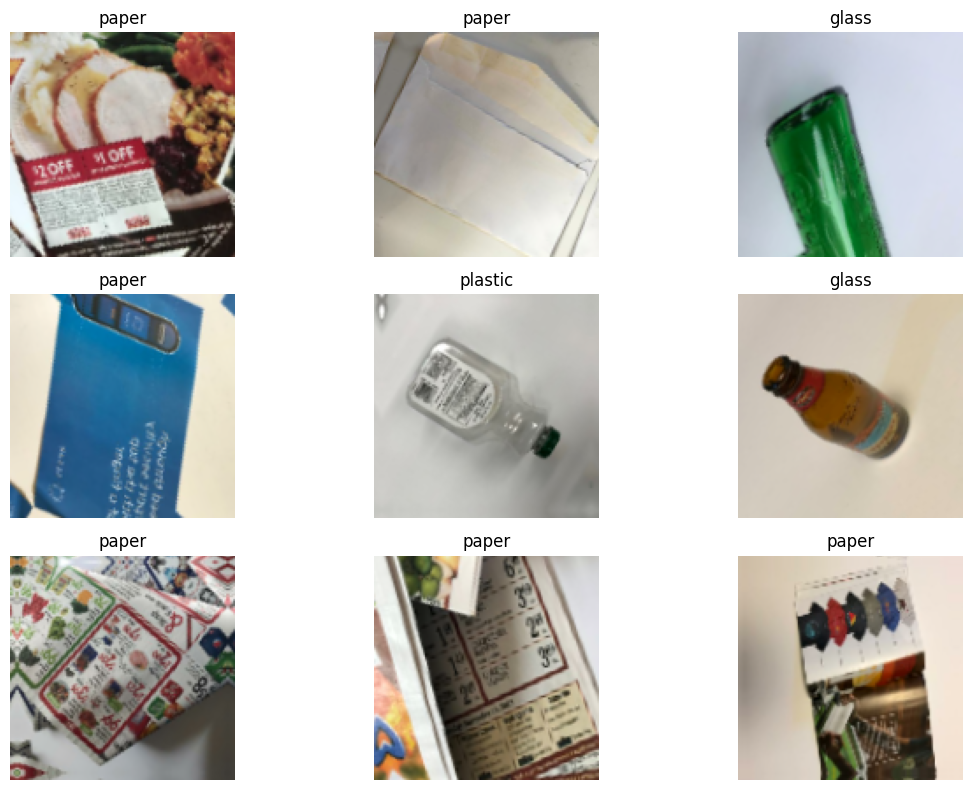

In [40]:
augmented_images, augmented_labels = next(iter(augmented_train_dataset))

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(class_names[augmented_labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

The augmented images are visualized to verify that realistic transformations
are being applied while preserving the original waste categories.

## Optimize Dataset Pipeline

In [41]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset_final = augmented_train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset_final = normalized_validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset_final = normalized_test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipeline optimized successfully.")

Dataset pipeline optimized successfully.


The dataset pipeline is optimized using prefetching to improve data loading
efficiency and maintain better GPU utilization during CNN training.

## Build CNN Model

In [42]:
model = keras.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation="softmax")
])

print("CNN model created successfully.")

CNN model created successfully.


The CNN consists of multiple convolutional blocks for feature extraction,
followed by global average pooling and dropout-based regularization for
multi-class waste classification.

### Inspect Model Architecture

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

The model summary displays the CNN architecture, layer structure, output
shapes, and total number of trainable parameters.

## Compile CNN Model

In [45]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


The CNN is compiled using the Adam optimizer, sparse categorical crossentropy
loss, and accuracy as the primary training performance metric.

## Configure Training Callbacks

In [46]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

callbacks = [
    early_stopping,
    reduce_lr
]

print("Training callbacks configured successfully.")

Training callbacks configured successfully.


Early stopping prevents unnecessary training when validation performance stops
improving, while learning-rate reduction helps the model continue learning
more effectively during training.

## Train CNN Model

In [47]:
EPOCHS = 30

history = model.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 319ms/step - accuracy: 0.4586 - loss: 1.5090 - val_accuracy: 0.2387 - val_loss: 1.7673 - learning_rate: 0.0010
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.5425 - loss: 1.2560 - val_accuracy: 0.1910 - val_loss: 2.0854 - learning_rate: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.5669 - loss: 1.1620 - val_accuracy: 0.2440 - val_loss: 1.9368 - learning_rate: 0.0010
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.5975 - loss: 1.0940 - val_accuracy: 0.1910 - val_loss: 3.2512 - learning_rate: 0.0010
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.6315 - loss: 1.0258 - val_accuracy: 0.2599 - val_loss: 1.7203 - learning_rate: 5.0000e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.6570 - loss: 0.9451 - val_accuracy: 0.2520 - val_loss: 2.1031 - learning_rate: 5.0000e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.6757 - loss:

## Analyze Training History

In [48]:
history_df = pd.DataFrame(history.history)

print("Training History:")
display(history_df)

print("\nBest Validation Accuracy:",
      history_df["val_accuracy"].max())

print("Best Validation Loss:",
      history_df["val_loss"].min())

print("\nFinal Training Accuracy:",
      history_df["accuracy"].iloc[-1])

print("Final Validation Accuracy:",
      history_df["val_accuracy"].iloc[-1])

Training History:


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.458617,1.509039,0.238727,1.767317,0.001000
1,0.542517,1.256033,0.190981,2.085369,0.001000
2,0.566893,1.161991,0.244032,1.936769,0.001000
3,0.597506,1.093982,0.190981,3.251237,0.001000
4,0.631519,1.025792,0.259947,1.720298,0.000500
5,0.657029,0.945079,0.251989,2.103106,0.000500
6,0.675737,0.929849,0.485411,1.321548,0.000500
7,0.673469,0.906081,0.480106,1.368039,0.000500
8,0.693878,0.842938,0.541114,1.178896,0.000500
9,0.695011,0.836939,0.623342,1.018134,0.000500



Best Validation Accuracy: 0.7745358347892761
Best Validation Loss: 0.6501347422599792

Final Training Accuracy: 0.795918345451355
Final Validation Accuracy: 0.7533156275749207


The training history is analyzed to compare training and validation performance
and identify the best validation accuracy achieved by the CNN.

## Training and Validation Accuracy

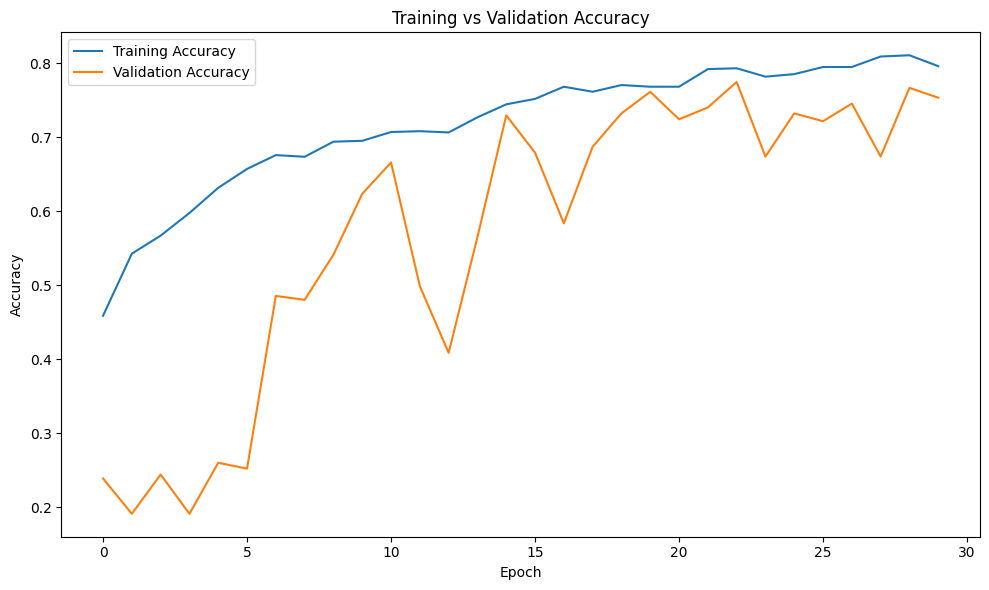

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

The accuracy curves compare training and validation performance across epochs
to evaluate learning progress and identify possible overfitting.

## Training and Validation Loss

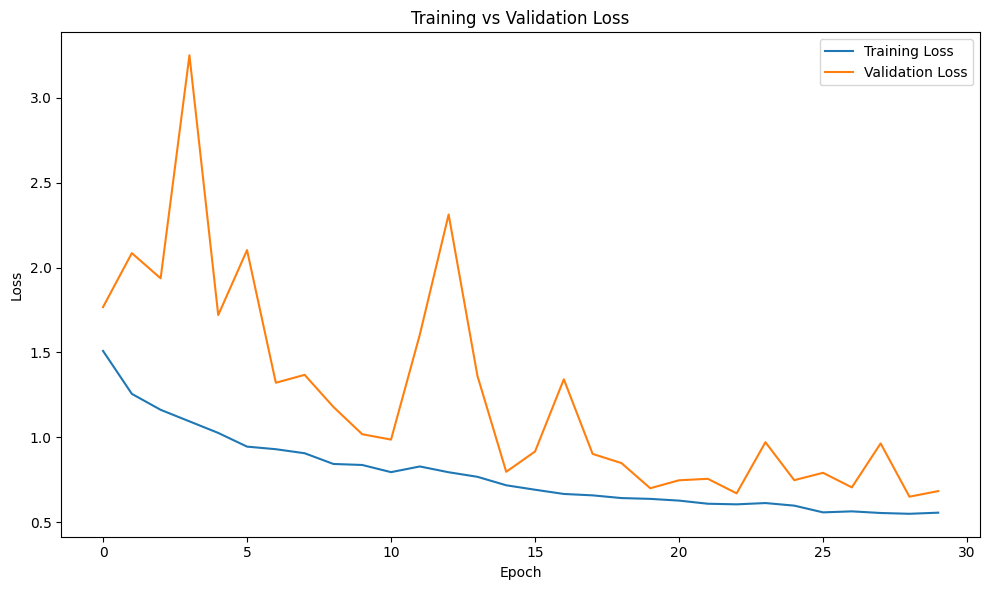

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The loss curves show how the training and validation errors change across
epochs, helping assess model convergence and generalization.

## Evaluate CNN on Test Dataset

In [51]:
test_loss, test_accuracy = model.evaluate(
    test_dataset_final,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.7467 - loss: 0.7187

Test Loss: 0.7187
Test Accuracy: 0.7467
Test Accuracy: 74.67%


The trained CNN is evaluated on the unseen test dataset to measure its
generalization performance on previously unseen waste images.

## Generate Test Predictions

In [52]:
y_true = []
y_pred = []

for images, labels in test_dataset_final:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total Test Samples:", len(y_true))
print("Predictions Generated:", len(y_pred))

Total Test Samples: 383
Predictions Generated: 383


Predictions are generated for every test image so that class-wise performance
and classification errors can be analyzed in detail.

## Classification Report

In [53]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

   cardboard     0.9107    0.8361    0.8718        61
       glass     0.7833    0.6184    0.6912        76
       metal     0.5529    0.7581    0.6395        62
       paper     0.7961    0.9111    0.8497        90
     plastic     0.7966    0.6528    0.7176        72
       trash     0.6000    0.5455    0.5714        22

    accuracy                         0.7467       383
   macro avg     0.7400    0.7203    0.7235       383
weighted avg     0.7613    0.7467    0.7469       383



The classification report provides precision, recall, and F1-score for each
waste category, giving a detailed view of the CNN's classification performance.

## Confusion Matrix

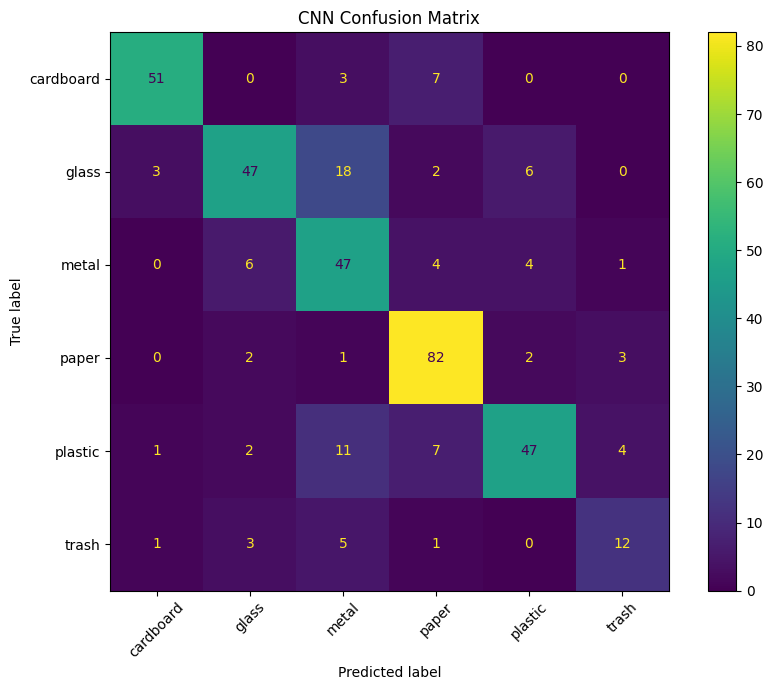

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=45
)

plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix shows the correct and incorrect predictions for each
waste category and helps identify the classes that are most frequently confused.

## Visualize Misclassified Images

Total Misclassified Images: 97


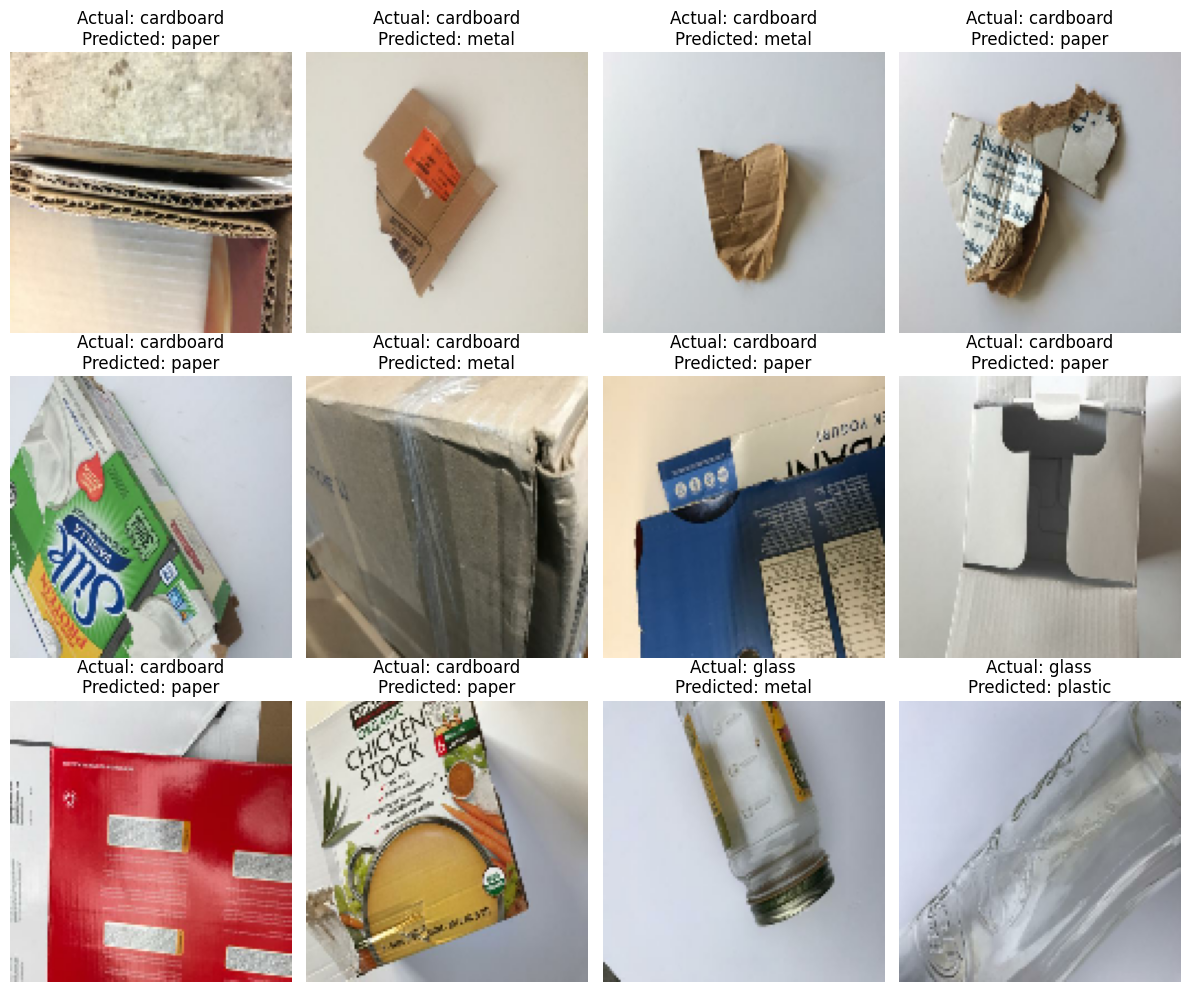

In [55]:
misclassified_indices = np.where(y_true != y_pred)[0]

print("Total Misclassified Images:", len(misclassified_indices))

plt.figure(figsize=(12, 10))

for i, index in enumerate(misclassified_indices[:12]):

    image, true_label = list(test_dataset_final.unbatch())[index]

    predicted_label = y_pred[index]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        f"Actual: {class_names[true_label.numpy()]}\n"
        f"Predicted: {class_names[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

The misclassified test images are visualized to understand the visual patterns
that cause the CNN to make incorrect predictions.

## Analyze Class-wise Performance

In [56]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_score, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    zero_division=0
)

class_performance = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score,
    "Support": support
})

class_performance

,Class,Precision,Recall,F1-Score,Support
0,cardboard,0.910714,0.836066,0.871795,61
1,glass,0.783333,0.618421,0.691176,76
2,metal,0.552941,0.758065,0.639456,62
3,paper,0.796117,0.911111,0.849741,90
4,plastic,0.796610,0.652778,0.717557,72
5,trash,0.600000,0.545455,0.571429,22


Class-wise precision, recall, and F1-score are analyzed to identify the waste
categories where the CNN performs strongly or requires further improvement.

# Calculate Class Weights

In [57]:
from sklearn.utils.class_weight import compute_class_weight

# Collect training labels
y_train = []

for _, labels in train_dataset_final:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

# Calculate balanced class weights
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=y_train
)

class_weights = {
    index: float(weight)
    for index, weight in enumerate(class_weights_array)
}

print("Class Weights:")

for index, weight in class_weights.items():
    print(f"{class_names[index]}: {weight:.4f}")

Class Weights:
cardboard: 1.0426
glass: 0.8400
metal: 1.0280
paper: 0.7084
plastic: 0.8750
trash: 3.0947


Balanced class weights are calculated to give greater importance to
underrepresented waste categories during model training.

## Build Improved CNN Model

In [58]:
model_2 = keras.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Block 4
    layers.Conv2D(256, (3, 3), padding="same", activation="relu",
                  kernel_regularizer=keras.regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.0001)
    ),
    layers.Dropout(0.40),
    layers.Dense(len(class_names), activation="softmax")
])

print("Improved CNN Model 2 created successfully.")

Improved CNN Model 2 created successfully.


The improved CNN uses deeper convolutional feature extraction, batch
normalization, dropout, and L2 regularization to improve generalization.

## Inspect Improved CNN Model

In [59]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 618,662 (2.36 MB)

 Trainable params: 617,254 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

The model summary is inspected to verify the improved CNN architecture and its
trainable parameter count before training.

## Compile Improved CNN Model

In [60]:
model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Improved CNN model compiled successfully.")

Improved CNN model compiled successfully.


The improved CNN is compiled with a reduced learning rate to allow more
controlled weight updates during training.


## Configure Model 2 Callbacks

In [61]:
early_stopping_2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr_2 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

callbacks_2 = [
    early_stopping_2,
    reduce_lr_2
]

print("Model 2 callbacks configured successfully.")

Model 2 callbacks configured successfully.


Early stopping and adaptive learning-rate reduction are used to improve
generalization and prevent unnecessary training.

## Train Improved CNN Model

In [62]:
history_2 = model_2.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks_2
)

Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 448ms/step - accuracy: 0.4388 - loss: 1.5803 - val_accuracy: 0.1989 - val_loss: 1.8709 - learning_rate: 5.0000e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.4983 - loss: 1.3807 - val_accuracy: 0.0955 - val_loss: 2.1221 - learning_rate: 5.0000e-04
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - accuracy: 0.5488 - loss: 1.2464 - val_accuracy: 0.3103 - val_loss: 2.1313 - learning_rate: 5.0000e-04
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.5760 - loss: 1.2108 - val_accuracy: 0.2387 - val_loss: 1.9765 - learning_rate: 5.0000e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.6094 - loss: 1.0782 - val_accuracy: 0.3156 - val_loss: 2.0291 - learning_rate: 2.5000e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.6519 - loss: 1.0300 - val_accuracy: 0.2971 - val_loss: 1.8758 - learning_rate: 2.5000e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accura

The improved CNN is trained using balanced class weights so that minority
categories receive greater attention during optimization.


## Evaluate Improved CNN on Test Dataset

In [63]:
test_loss_2, test_accuracy_2 = model_2.evaluate(
    test_dataset_final,
    verbose=1
)

print(f"\nModel 2 Test Loss: {test_loss_2:.4f}")
print(f"Model 2 Test Accuracy: {test_accuracy_2:.4f}")
print(f"Model 2 Test Accuracy: {test_accuracy_2 * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 308ms/step - accuracy: 0.7023 - loss: 0.9361

Model 2 Test Loss: 0.9361
Model 2 Test Accuracy: 0.7023
Model 2 Test Accuracy: 70.23%


The improved CNN is evaluated on the unseen test dataset to determine whether
the updated architecture and class weighting improved generalization.

## Compare CNN Models

In [64]:
model_comparison = pd.DataFrame({
    "Model": ["CNN Model 1", "Improved CNN Model 2"],
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_2
    ],
    "Test Loss": [
        test_loss,
        test_loss_2
    ]
})

display(model_comparison)

improvement = (test_accuracy_2 - test_accuracy) * 100

print(f"Accuracy Improvement: {improvement:.2f} percentage points")

if test_accuracy_2 > test_accuracy:
    print("Model 2 performed better than Model 1.")
else:
    print("Model 1 performed better than Model 2.")

,Model,Test Accuracy,Test Loss
0,CNN Model 1,0.746736,0.718662
1,Improved CNN Model 2,0.702350,0.936109


Accuracy Improvement: -4.44 percentage points
Model 1 performed better than Model 2.


The performance of both CNN models is compared using test accuracy and test
loss to select the best-performing model for final deployment.

## Load Pretrained MobileNetV2

In [65]:
base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded successfully.")
print("Pretrained layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
Pretrained layers: 154


MobileNetV2 pretrained on ImageNet is used as a feature extractor while its
pretrained weights remain frozen during the initial training stage.

## Build Transfer Learning Model

In [66]:
inputs = keras.Input(shape=(128, 128, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.0001)
)(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model_3 = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Transfer_Learning"
)

print("Transfer Learning Model 3 created successfully.")

Transfer Learning Model 3 created successfully.


A lightweight classification head is added on top of the frozen MobileNetV2
feature extractor to classify the six waste categories.

## Compile Transfer Learning Model

In [67]:
model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model 3 compiled successfully.")

Model 3 compiled successfully.


The transfer learning model is compiled with Adam optimization and sparse
categorical crossentropy for six-class classification.

## Train Transfer Learning Model

In [68]:
early_stopping_3 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_3 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_3 = model_3.fit(
    train_dataset_final,
    validation_data=validation_dataset_final,
    epochs=20,
    callbacks=[early_stopping_3, reduce_lr_3]
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 68s 661ms/step - accuracy: 0.4745 - loss: 1.4454 - val_accuracy: 0.6499 - val_loss: 0.9471 - learning_rate: 0.0010
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.6553 - loss: 0.9227 - val_accuracy: 0.7480 - val_loss: 0.7907 - learning_rate: 0.0010
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - accuracy: 0.7132 - loss: 0.7803 - val_accuracy: 0.7507 - val_loss: 0.7836 - learning_rate: 0.0010
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7296 - loss: 0.7341 - val_accuracy: 0.7427 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.7562 - loss: 0.6668 - val_accuracy: 0.7692 - val_loss: 0.7380 - learning_rate: 0.0010
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - accuracy: 0.7880 - loss: 0.6183 - val_accuracy: 0.7745 - val_loss: 0.7111 - learning_rate: 0.0010
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.7891 - loss: 0.5856

The frozen MobileNetV2 model is trained for a limited number of epochs while
validation performance is monitored to select the best generalizing weights.

## Evaluate Transfer Learning Model

In [69]:
test_loss_3, test_accuracy_3 = model_3.evaluate(
    test_dataset_final,
    verbose=1
)

print(f"\nModel 3 Test Loss: {test_loss_3:.4f}")
print(f"Model 3 Test Accuracy: {test_accuracy_3:.4f}")
print(f"Model 3 Test Accuracy: {test_accuracy_3 * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7859 - loss: 0.6441

Model 3 Test Loss: 0.6441
Model 3 Test Accuracy: 0.7859
Model 3 Test Accuracy: 78.59%


The transfer learning model is evaluated on the unseen test dataset to
measure its generalization performance.

## Compare All CNN Models

In [70]:
model_comparison = pd.DataFrame({
    "Model": [
        "CNN Model 1",
        "Improved CNN Model 2",
        "MobileNetV2 Model 3"
    ],
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_2,
        test_accuracy_3
    ],
    "Test Loss": [
        test_loss,
        test_loss_2,
        test_loss_3
    ]
})

display(model_comparison)

best_model_index = model_comparison["Test Accuracy"].idxmax()
best_model_name = model_comparison.loc[best_model_index, "Model"]
best_accuracy = model_comparison.loc[best_model_index, "Test Accuracy"]

print(f"\nBest Model: {best_model_name}")
print(f"Best Test Accuracy: {best_accuracy * 100:.2f}%")

,Model,Test Accuracy,Test Loss
0,CNN Model 1,0.746736,0.718662
1,Improved CNN Model 2,0.702350,0.936109
2,MobileNetV2 Model 3,0.785901,0.644086



Best Model: MobileNetV2 Model 3
Best Test Accuracy: 78.59%


The three CNN approaches are compared using test accuracy and test loss.
The model with the highest test accuracy is selected as the final model.

## Final Model Predictions

In [71]:
y_true_final = []
y_pred_final = []

for images, labels in test_dataset_final:
    predictions = model_3.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true_final.extend(labels.numpy())
    y_pred_final.extend(predicted_labels)

y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)

print("Test Samples:", len(y_true_final))
print("Predictions:", len(y_pred_final))

Test Samples: 383
Predictions: 383


Predictions from the best-performing MobileNetV2 model are generated on the
unseen test dataset for final performance analysis.

## Final Classification Report

In [72]:
from sklearn.metrics import classification_report

final_report = classification_report(
    y_true_final,
    y_pred_final,
    target_names=class_names,
    digits=4
)

print(final_report)

              precision    recall  f1-score   support

   cardboard     0.8030    0.8689    0.8346        61
       glass     0.8116    0.7368    0.7724        76
       metal     0.6923    0.8710    0.7714        62
       paper     0.8571    0.8000    0.8276        90
     plastic     0.7794    0.7361    0.7571        72
       trash     0.7222    0.5909    0.6500        22

    accuracy                         0.7859       383
   macro avg     0.7776    0.7673    0.7689       383
weighted avg     0.7904    0.7859    0.7852       383



The classification report provides the final precision, recall, and F1-score
for each waste category using the selected MobileNetV2 model.

## Final Confusion Matrix

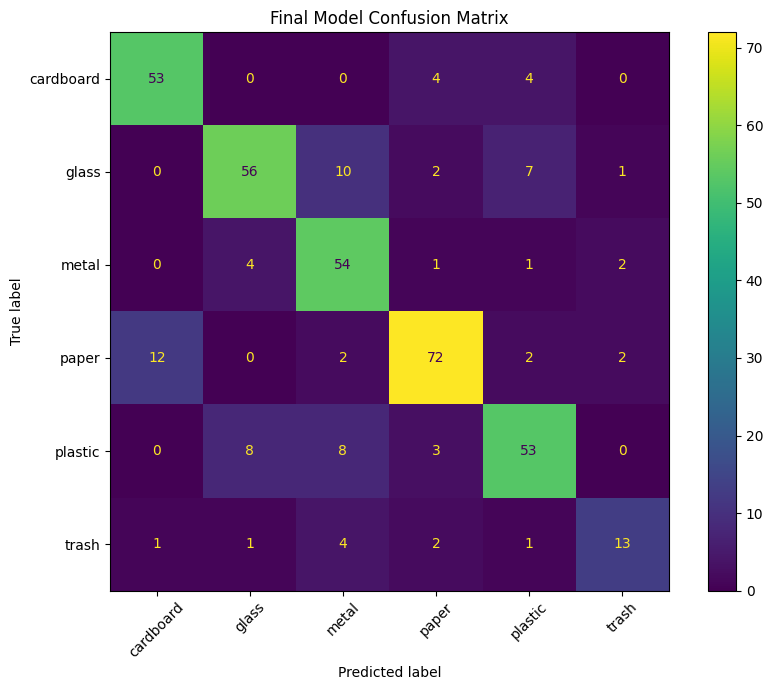

In [73]:
cm_final = confusion_matrix(
    y_true_final,
    y_pred_final
)

plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=class_names
)

disp.plot(
    ax=plt.gca(),
    xticks_rotation=45
)

plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()

The final confusion matrix visualizes correct and incorrect predictions across
all six waste categories and highlights the remaining classification errors.

## Save Final Model

In [74]:
final_model_path = "/content/EcoVision_AI/waste_classifier_mobilenetv2.keras"

model_3.save(final_model_path)

print("Final model saved successfully.")
print("Model path:", final_model_path)

Final model saved successfully.
Model path: /content/EcoVision_AI/waste_classifier_mobilenetv2.keras


The best-performing MobileNetV2 model is saved in Keras format for reuse during
deployment without requiring the model to be retrained.

## Verify Saved Model Artifact

In [75]:
import os

if os.path.exists(final_model_path):
    file_size_mb = os.path.getsize(final_model_path) / (1024 ** 2)

    print("Artifact verified successfully.")
    print(f"File size: {file_size_mb:.2f} MB")
    print("Artifact:", final_model_path)
else:
    print("Artifact was not found.")

Artifact verified successfully.
File size: 11.07 MB
Artifact: /content/EcoVision_AI/waste_classifier_mobilenetv2.keras


The saved model artifact is verified to ensure that the final trained model
is available for deployment.

## Verify Final Model Loading

In [76]:
loaded_model = keras.models.load_model(final_model_path)

print("Final model loaded successfully.")
print("Model name:", loaded_model.name)
print("Output classes:", loaded_model.output_shape[-1])

Final model loaded successfully.
Model name: MobileNetV2_Transfer_Learning
Output classes: 6


The saved model artifact is loaded again to confirm that it can be successfully
restored and is ready for deployment.

In [77]:
from google.colab import files

files.download("/content/EcoVision_AI/waste_classifier_mobilenetv2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>